# Uncertainty-Aware Colorization

Standard colorization models predict a single color per pixel, but colorization
is ill-posed: many colors are plausible for the same gray patch. This model
predicts **both** a color and a **confidence** for each pixel.

The architecture adds a lightweight uncertainty head (a single 1Ã—1 conv) on top
of the pretrained generator. The head predicts log-variance per ab channel. The
reconstruction loss switches from L1 to Gaussian NLL:

```
L_nll = 0.5 * (log_var + (ab_pred - ab_gt)^2 * exp(-log_var))
```

This forces the model to be uncertain where it genuinely cannot predict the right
color (flat walls, metal, concrete), and confident where context is clear (sky,
grass, skin).

The uncertainty map is a direct output of the model â€” no extra inference needed.

**Training strategy**: load the pretrained baseline generator, freeze it for the
first few epochs so only the uncertainty head trains, then unfreeze everything
for fine-tuning.


In [1]:
!pip install fastai>=2.7 scikit-image tqdm -q


In [2]:
import os
import glob
import numpy as np
from PIL import Image
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from skimage.color import rgb2lab, lab2rgb

import torch
from torch import nn, optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

from fastai.vision.learner import create_body
from torchvision.models.resnet import resnet18
from fastai.vision.models.unet import DynamicUnet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
SIZE = 256
BASELINE_CHECKPOINT_DIR  = "/content/drive/MyDrive/colorization_checkpoints"
UNCERTAINTY_CHECKPOINT_DIR = "/content/drive/MyDrive/colorization_checkpoints_uncertainty"
os.makedirs(UNCERTAINTY_CHECKPOINT_DIR, exist_ok=True)


## Model Definitions

In [5]:
def build_res_unet(n_input=1, n_output=2, size=256):
    try:
        from torchvision.models import ResNet18_Weights
        model = resnet18(weights='DEFAULT')
    except:
        try:
            model = resnet18(pretrained=True)
        except:
            model = resnet18(pretrained=False)
            print("warning: no pretrained weights")

    if n_input == 1:
        old_conv = model.conv1
        with torch.no_grad():
            new_conv = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
            new_conv.weight.data = old_conv.weight.data.mean(dim=1, keepdim=True)
        model.conv1 = new_conv

    body = create_body(model, cut=-2)
    return DynamicUnet(body, n_output, (size, size)).to(device)


class UncertaintyGenerator(nn.Module):
    """
    Wraps the pretrained colorization generator and adds a 1x1 conv uncertainty head.
    Forward returns (ab_mean, log_var), both [B, 2, H, W].
    """
    def __init__(self, base_generator):
        super().__init__()
        self.base = base_generator
        self.logvar_head = nn.Conv2d(2, 2, kernel_size=1)
        nn.init.zeros_(self.logvar_head.weight)
        nn.init.constant_(self.logvar_head.bias, -2.0)  # start with low uncertainty

    def forward(self, L):
        ab_mean = self.base(L)
        log_var = self.logvar_head(ab_mean)
        return ab_mean, log_var


class PatchDiscriminator(nn.Module):
    def __init__(self, input_c, num_filters=64, n_down=3):
        super().__init__()
        self.model = self.get_layers(input_c, num_filters, n_down)

    def get_layers(self, input_c, num_filters, n_down):
        model = [self.get_conv(input_c, num_filters, norm=False)]
        for i in range(n_down):
            model += [self.get_conv(num_filters * 2**i, num_filters * 2**(i+1),
                                    stride=1 if i == (n_down - 1) else 2)]
        model += [self.get_conv(num_filters * 2**n_down, 1, stride=1, norm=False, act=False)]
        return nn.Sequential(*model)

    def get_conv(self, in_c, out_c, kernel_size=4, stride=2, padding=1, norm=True, act=True):
        layers = [nn.Conv2d(in_c, out_c, kernel_size, stride, padding, bias=not norm)]
        if norm: layers.append(nn.BatchNorm2d(out_c))
        if act:  layers.append(nn.LeakyReLU(0.2, True))
        return nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class GANLoss(nn.Module):
    def __init__(self, real_label=1.0, fake_label=0.0):
        super().__init__()
        self.register_buffer('real_label', torch.tensor(real_label))
        self.register_buffer('fake_label', torch.tensor(fake_label))
        self.loss = nn.BCEWithLogitsLoss()
    def get_labels(self, preds, is_real):
        return (self.real_label if is_real else self.fake_label).expand_as(preds)
    def __call__(self, preds, is_real):
        return self.loss(preds, self.get_labels(preds, is_real))


def init_weights(net, gain=0.02):
    def fn(m):
        cn = m.__class__.__name__
        if hasattr(m, 'weight') and 'Conv' in cn:
            nn.init.normal_(m.weight.data, 0.0, gain)
            if hasattr(m, 'bias') and m.bias is not None:
                nn.init.constant_(m.bias.data, 0.0)
        elif 'BatchNorm2d' in cn:
            nn.init.normal_(m.weight.data, 1.0, gain)
            nn.init.constant_(m.bias.data, 0.0)
    net.apply(fn)
    return net

def init_model(model, device):
    return init_weights(model.to(device))

def total_variation_loss(img):
    return (torch.abs(img[:,:,:,:-1] - img[:,:,:,1:]).mean() +
            torch.abs(img[:,:,:-1,:] - img[:,:,1:,:]).mean())


class AverageMeter:
    def __init__(self):
        self.reset()
    def reset(self):
        self.count, self.avg, self.sum = [0.] * 3
    def update(self, val, count=1):
        self.count += count
        self.sum   += count * val
        self.avg    = self.sum / self.count


print("definitions loaded")


definitions loaded


## Gaussian NLL Loss

In [ ]:
import torch.nn.functional as F
import shutil

def save_checkpoint(state, remote_dir, filename):
    """Save checkpoint to /content/ first (Drive writer unsupported by PyTorch),
    then copy to Drive.
    """
    local_path = f'/content/{filename}'
    torch.save(state, local_path)
    remote_path = os.path.join(remote_dir, filename)
    shutil.copy2(local_path, remote_path)
    print(f'  saved {remote_path}')
    return remote_path


def reconstruction_loss(ab_mean, ab_target):
    """L1 colorization loss. Stable gradient, no interaction with uncertainty head."""
    return F.l1_loss(ab_mean, ab_target)


def uncertainty_supervision_loss(log_var, ab_mean, ab_target):
    """Directly teach log_var to predict log(per-pixel MSE).

    Why not NLL?
    NLL gradient w.r.t. log_var = 0.5*(1 - error^2*exp(-log_var)).
    When reconstruction is good (small error), this is ALWAYS positive,
    pushing log_var to the +3 clamp boundary unconditionally -- no equilibrium
    exists inside [-3, 3] for small errors. Uncertainty collapses high.

    This loss directly supervises log_var toward log(error^2). The gradient
    is 2*(log_var_c - log_target), zero at the calibrated value and pulling
    in the correct direction on both sides.
    """
    with torch.no_grad():
        error_sq = (ab_mean - ab_target).pow(2).mean(dim=1, keepdim=True)
        log_target = torch.log(error_sq.clamp(min=1e-8)).clamp(-3.0, 3.0)
        log_target = log_target.expand_as(log_var)
    log_var_c = torch.clamp(log_var, -3.0, 3.0)
    return F.mse_loss(log_var_c, log_target)


def spatial_diversity_loss(log_var):
    """Penalize spatially uniform uncertainty.
    MUST clamp log_var first: raw head output is unbounded,
    var(unbounded) can reach 1e19 and destroy training.
    """
    log_var_c = torch.clamp(log_var, -3.0, 3.0)
    return -log_var_c.var(dim=[2, 3]).mean()


print('loss functions defined')


## Main Model

In [ ]:
class MainModel(nn.Module):
    def __init__(self, net_G, lr_G=2e-4, lr_D=2e-4, beta1=0.5, beta2=0.999,
                 lambda_recon=1.0, lambda_TV=0.5, lambda_unc=0.5, lambda_div=0.01):
        super().__init__()
        self.device       = device
        self.lambda_recon = lambda_recon
        self.lambda_TV    = lambda_TV
        self.lambda_unc   = lambda_unc
        self.lambda_div   = lambda_div
        self.net_G = net_G.to(device)
        self.net_D = init_model(PatchDiscriminator(input_c=3, n_down=3, num_filters=64), device)
        self.GAN   = GANLoss().to(device)
        self.opt_G = optim.Adam(self.net_G.parameters(), lr=lr_G, betas=(beta1, beta2))
        self.opt_D = optim.Adam(self.net_D.parameters(), lr=lr_D, betas=(beta1, beta2))

    def set_requires_grad(self, m, v):
        for p in m.parameters():
            p.requires_grad = v

    def setup_input(self, data):
        self.L  = data['L'].to(device)
        self.ab = data['ab'].to(device)

    def forward(self):
        self.ab_mean, self.log_var = self.net_G(self.L)
        self.uncertainty = torch.sqrt(
            torch.exp(torch.clamp(self.log_var, -3, 3)).mean(dim=1, keepdim=True)
        )

    def backward_D(self):
        fake_img  = torch.cat([self.L, self.ab_mean.detach()], dim=1)
        real_img  = torch.cat([self.L, self.ab], dim=1)
        self.loss_D_fake = self.GAN(self.net_D(fake_img), False)
        self.loss_D_real = self.GAN(self.net_D(real_img), True)
        self.loss_D = (self.loss_D_fake + self.loss_D_real) * 0.5
        self.loss_D.backward()

    def backward_G(self):
        fake_img = torch.cat([self.L, self.ab_mean], dim=1)
        self.loss_G_GAN   = self.GAN(self.net_D(fake_img), True)
        self.loss_G_recon = reconstruction_loss(self.ab_mean, self.ab) * self.lambda_recon
        self.loss_G_TV    = total_variation_loss(fake_img) * self.lambda_TV
        self.loss_G_unc   = uncertainty_supervision_loss(self.log_var, self.ab_mean, self.ab) * self.lambda_unc
        self.loss_G_div   = spatial_diversity_loss(self.log_var) * self.lambda_div
        self.loss_G = (self.loss_G_GAN + self.loss_G_recon + self.loss_G_TV
                       + self.loss_G_unc + self.loss_G_div)
        self.loss_G.backward()

    def optimize(self, d_update_freq=1):
        self.forward()
        self._step = getattr(self, '_step', 0) + 1
        if self._step % d_update_freq == 0:
            self.net_D.train(); self.set_requires_grad(self.net_D, True)
            self.opt_D.zero_grad(); self.backward_D(); self.opt_D.step()
        else:
            with torch.no_grad():
                fi = torch.cat([self.L, self.ab_mean.detach()], dim=1)
                ri = torch.cat([self.L, self.ab], dim=1)
                self.loss_D_fake = self.GAN(self.net_D(fi), False)
                self.loss_D_real = self.GAN(self.net_D(ri), True)
                self.loss_D = (self.loss_D_fake + self.loss_D_real) * 0.5
        self.net_G.train(); self.set_requires_grad(self.net_D, False)
        self.opt_G.zero_grad(); self.backward_G()
        torch.nn.utils.clip_grad_norm_(self.net_G.parameters(), max_norm=1.0)
        self.opt_G.step()


print('MainModel defined')


## Dataset

In [8]:
DATASET_PATH = "/content/drive/MyDrive/datasets/coco_subset_16000"
NUM_IMAGES   = 13000

class ColorizationDataset(Dataset):
    def __init__(self, paths, split='train'):
        self.paths = paths
        if split == 'train':
            self.transforms = transforms.Compose([
                transforms.Resize((256, 256), Image.BICUBIC),
                transforms.RandomHorizontalFlip(),
            ])
        else:
            self.transforms = transforms.Resize((256, 256), Image.BICUBIC)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        img_lab = rgb2lab(np.array(self.transforms(img))).astype("float32")
        img_lab = transforms.ToTensor()(img_lab)
        return {'L': img_lab[[0]] / 50. - 1., 'ab': img_lab[[1, 2]] / 110.}

    def __len__(self):
        return len(self.paths)

def make_dataloaders(paths, split='train', batch_size=16, n_workers=2):
    return DataLoader(ColorizationDataset(paths, split), batch_size=batch_size,
                      num_workers=n_workers, pin_memory=True, shuffle=(split=='train'))

image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']
paths = []
for ext in image_extensions:
    paths.extend(glob.glob(os.path.join(DATASET_PATH, ext)))
    paths.extend(glob.glob(os.path.join(DATASET_PATH, '**', ext), recursive=True))

if not paths:
    raise RuntimeError(f"no images found in {DATASET_PATH}")

np.random.seed(123)
if len(paths) > NUM_IMAGES:
    paths = np.random.choice(paths, NUM_IMAGES, replace=False)

rand_idxs   = np.random.permutation(len(paths))
train_paths = paths[rand_idxs[:int(len(paths) * 0.8)]]
val_paths   = paths[rand_idxs[int(len(paths) * 0.8):]]

train_dl = make_dataloaders(train_paths, 'train', batch_size=16, n_workers=2)
val_dl   = make_dataloaders(val_paths,   'val',   batch_size=16, n_workers=2)
print(f"train: {len(train_paths)}  val: {len(val_paths)}")


train: 10400  val: 2600


## Load Pretrained Generator + Build Uncertainty Model

In [9]:
base_G = build_res_unet(n_input=1, n_output=2, size=SIZE)

pretrained_path = os.path.join(BASELINE_CHECKPOINT_DIR, "pretrained_generator.pth")
if os.path.exists(pretrained_path):
    base_G.load_state_dict(torch.load(pretrained_path, map_location=device))
    print(f"loaded pretrained generator from {pretrained_path}")
else:
    print(f"pretrained generator not found at {pretrained_path}")
    print("the uncertainty head can still train, but results will be weaker")

net_G = UncertaintyGenerator(base_G)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 44.7M/44.7M [00:00<00:00, 76.7MB/s]


pretrained generator not found at /content/drive/MyDrive/colorization_checkpoints/pretrained_generator.pth
the uncertainty head can still train, but results will be weaker


## Training

Two-phase strategy:
1. **Phase 1 (5 epochs)**: freeze the base generator, train only the uncertainty head.
   The head learns to assign uncertainty to ambiguous regions without disturbing
   the pretrained color predictions.
2. **Phase 2 (15 epochs)**: unfreeze everything and fine-tune jointly.


In [ ]:
LAMBDA_RECON  = 1.0    # L1 colorization weight
LAMBDA_TV     = 0.5
LAMBDA_UNC    = 0.5    # uncertainty supervision: teaches log_var to match log(MSE)
LAMBDA_DIV    = 0.01   # diversity: small -- log_var clamped to [-3,3] so range is bounded
GAN_EPOCHS    = 20
DISPLAY_EVERY = 200
PHASE1_EPOCHS = 10
PHASE1_CKPT   = 'phase1_final.pth'
FORCE_PHASE1  = False  # set True to re-run phase 1 and overwrite existing checkpoint

model = MainModel(
    net_G=net_G,
    lambda_recon=LAMBDA_RECON, lambda_TV=LAMBDA_TV,
    lambda_unc=LAMBDA_UNC, lambda_div=LAMBDA_DIV,
)

# ── Phase 1: train only the uncertainty head (backbone frozen) ───────────────
# Loads existing checkpoint and skips training unless FORCE_PHASE1=True
phase1_remote = os.path.join(UNCERTAINTY_CHECKPOINT_DIR, PHASE1_CKPT)
phase1_local  = f'/content/{PHASE1_CKPT}'

if os.path.exists(phase1_remote) and not FORCE_PHASE1:
    shutil.copy2(phase1_remote, phase1_local)
    ckpt = torch.load(phase1_local, map_location=device)
    model.net_G.load_state_dict(ckpt['generator_state_dict'])
    print('phase 1 loaded from checkpoint -- skipping training (set FORCE_PHASE1=True to re-run)')
    SKIP_PHASE1 = True
else:
    if FORCE_PHASE1 and os.path.exists(phase1_remote):
        print('FORCE_PHASE1=True -- re-running phase 1 and overwriting existing checkpoint')
    SKIP_PHASE1 = False

if not SKIP_PHASE1:
    print('phase 1: training uncertainty head only (backbone frozen)')
    for p in model.net_G.base.parameters():
        p.requires_grad = False

    for e in range(PHASE1_EPOCHS):
        meters = {k: AverageMeter() for k in ['loss_D', 'loss_G_GAN', 'loss_G_recon',
                                               'loss_G_TV', 'loss_G_unc', 'loss_G_div', 'loss_G']}
        unc_meter = AverageMeter()
        for data in tqdm(train_dl, desc=f'phase1 epoch {e+1}/{PHASE1_EPOCHS}'):
            model.setup_input(data)
            model.optimize()
            for k, m in meters.items():
                if hasattr(model, k):
                    m.update(getattr(model, k).item(), data['L'].size(0))
            unc_meter.update(model.uncertainty.mean().item(), data['L'].size(0))
        print(f'  epoch {e+1}  recon: {meters["loss_G_recon"].avg:.4f}  '
              f'unc: {meters["loss_G_unc"].avg:.4f}  div: {meters["loss_G_div"].avg:.4f}  '
              f'unc mean/std: {unc_meter.avg:.4f}/{model.uncertainty.std().item():.4f}')

    save_checkpoint({'generator_state_dict': model.net_G.state_dict()},
                    UNCERTAINTY_CHECKPOINT_DIR, PHASE1_CKPT)
    print('phase 1 checkpoint saved')

# unfreeze for phase 2
for p in model.net_G.base.parameters():
    p.requires_grad = True
print('phase 2: fine-tuning full model')


In [11]:
RESUME_TRAINING    = False
CHECKPOINT_TO_LOAD = "checkpoint_epoch_10.pth"
START_EPOCH        = 10

if RESUME_TRAINING:
    ckpt_path = os.path.join(UNCERTAINTY_CHECKPOINT_DIR, CHECKPOINT_TO_LOAD)
    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=device)
        model.net_G.load_state_dict(ckpt['generator_state_dict'])
        model.net_D.load_state_dict(ckpt['discriminator_state_dict'])
        model.opt_G.load_state_dict(ckpt['optimizer_G_state_dict'])
        model.opt_D.load_state_dict(ckpt['optimizer_D_state_dict'])
        print(f"resumed from epoch {ckpt['epoch']}")
    else:
        print(f"checkpoint not found: {ckpt_path}")
        RESUME_TRAINING = False


resumed from epoch 15


In [ ]:
def compute_psnr(model, data_loader, max_batches=20):
    """PSNR on ab channels."""
    model.net_G.eval()
    mse_total, n = 0.0, 0
    with torch.no_grad():
        for i, data in enumerate(data_loader):
            if i >= max_batches: break
            model.setup_input(data)
            model.forward()
            mse = ((model.ab_mean - model.ab) ** 2).mean().item()
            mse_total += mse * data['L'].size(0)
            n += data['L'].size(0)
    model.net_G.train()
    mse_avg = mse_total / n
    return 10 * np.log10(4.0 / mse_avg) if mse_avg > 0 else float('inf')


sched_G = torch.optim.lr_scheduler.ReduceLROnPlateau(model.opt_G, mode='max', factor=0.5, patience=3)
sched_D = torch.optim.lr_scheduler.ReduceLROnPlateau(model.opt_D, mode='max', factor=0.5, patience=3)

class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience; self.best = -float('inf'); self.counter = 0; self.stop = False
    def step(self, metric):
        if metric > self.best: self.best = metric; self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience: self.stop = True

early_stop = EarlyStopping(patience=5)

loss_names = ['loss_D', 'loss_G_GAN', 'loss_G_recon', 'loss_G_TV', 'loss_G_unc', 'loss_G_div', 'loss_G']
history = {k: [] for k in loss_names + ['psnr', 'mean_unc', 'std_unc']}

RESUME_TRAINING    = False
CHECKPOINT_TO_LOAD = 'checkpoint_epoch_10.pth'
START_EPOCH        = 10

if RESUME_TRAINING:
    ckpt_remote = os.path.join(UNCERTAINTY_CHECKPOINT_DIR, CHECKPOINT_TO_LOAD)
    ckpt_local  = f'/content/{CHECKPOINT_TO_LOAD}'
    if os.path.exists(ckpt_remote):
        shutil.copy2(ckpt_remote, ckpt_local)
        ckpt = torch.load(ckpt_local, map_location=device)
        model.net_G.load_state_dict(ckpt['generator_state_dict'])
        model.net_D.load_state_dict(ckpt['discriminator_state_dict'])
        model.opt_G.load_state_dict(ckpt['optimizer_G_state_dict'])
        model.opt_D.load_state_dict(ckpt['optimizer_D_state_dict'])
        print(f'resumed from epoch {ckpt["epoch"]}')
    else:
        print(f'checkpoint not found: {ckpt_remote}')
        RESUME_TRAINING = False

for e in range(START_EPOCH if RESUME_TRAINING else 0, GAN_EPOCHS):
    meters = {k: AverageMeter() for k in loss_names}
    unc_meter = AverageMeter()
    i = 0

    for data in tqdm(train_dl, desc=f'epoch {e+1}/{GAN_EPOCHS}'):
        model.setup_input(data)
        model.optimize()
        for k, m in meters.items():
            if hasattr(model, k):
                m.update(getattr(model, k).item(), data['L'].size(0))
        unc_meter.update(model.uncertainty.mean().item(), data['L'].size(0))
        i += 1

        if i % DISPLAY_EVERY == 0:
            print(f'epoch {e+1}  iter {i}/{len(train_dl)}')
            for k, m in meters.items():
                print(f'  {k}: {m.avg:.5f}')
            print(f'  mean_uncertainty: {unc_meter.avg:.4f}')

    psnr_val = compute_psnr(model, val_dl, max_batches=20)
    unc_std  = model.uncertainty.std().item()

    for k, m in meters.items():
        history[k].append(m.avg)
    history['psnr'].append(psnr_val)
    history['mean_unc'].append(unc_meter.avg)
    history['std_unc'].append(unc_std)

    lr_now = model.opt_G.param_groups[0]['lr']
    print(f'epoch {e+1}  recon: {meters["loss_G_recon"].avg:.4f}  '
          f'unc: {meters["loss_G_unc"].avg:.4f}  div: {meters["loss_G_div"].avg:.4f}  '
          f'D: {meters["loss_D"].avg:.4f}  PSNR: {psnr_val:.2f} dB  '
          f'unc mean/std: {unc_meter.avg:.4f}/{unc_std:.4f}  lr: {lr_now:.2e}')

    sched_G.step(psnr_val)
    sched_D.step(psnr_val)
    early_stop.step(psnr_val)

    if (e + 1) % 5 == 0 or (e + 1) == GAN_EPOCHS:
        fname = f'checkpoint_epoch_{e+1}.pth'
        save_checkpoint({
            'epoch':                    e + 1,
            'generator_state_dict':     model.net_G.state_dict(),
            'discriminator_state_dict': model.net_D.state_dict(),
            'optimizer_G_state_dict':   model.opt_G.state_dict(),
            'optimizer_D_state_dict':   model.opt_D.state_dict(),
        }, UNCERTAINTY_CHECKPOINT_DIR, fname)

    if early_stop.stop:
        print(f'early stopping at epoch {e+1} (best PSNR: {early_stop.best:.2f} dB)')
        break

save_checkpoint({'generator_state_dict': model.net_G.state_dict()},
                UNCERTAINTY_CHECKPOINT_DIR, 'uncertainty_generator.pth')
print('training done')

# training curves
epochs_done = list(range(1, len(history['psnr']) + 1))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(epochs_done, history['loss_G_recon'], label='recon (L1)')
axes[0].plot(epochs_done, history['loss_G_GAN'],   label='GAN')
axes[0].plot(epochs_done, history['loss_D'],       label='D')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss')
axes[0].set_title('Training losses'); axes[0].legend(fontsize=8)
axes[1].plot(epochs_done, history['psnr'], 'o-', markersize=4)
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('PSNR (dB)')
axes[1].set_title('Validation PSNR')
axes[2].plot(epochs_done, history['mean_unc'], label='mean')
axes[2].plot(epochs_done, history['std_unc'],  label='std')
axes[2].set_xlabel('epoch'); axes[2].set_ylabel('uncertainty')
axes[2].set_title('Per-pixel uncertainty'); axes[2].legend(fontsize=8)
plt.tight_layout()
local_curves = '/content/training_curves.png'
plt.savefig(local_curves, bbox_inches='tight', dpi=120)
shutil.copy2(local_curves, os.path.join(UNCERTAINTY_CHECKPOINT_DIR, 'training_curves.png'))
plt.show()


## Visualize Uncertainty Maps

/tmp/ipykernel_927/2752852361.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


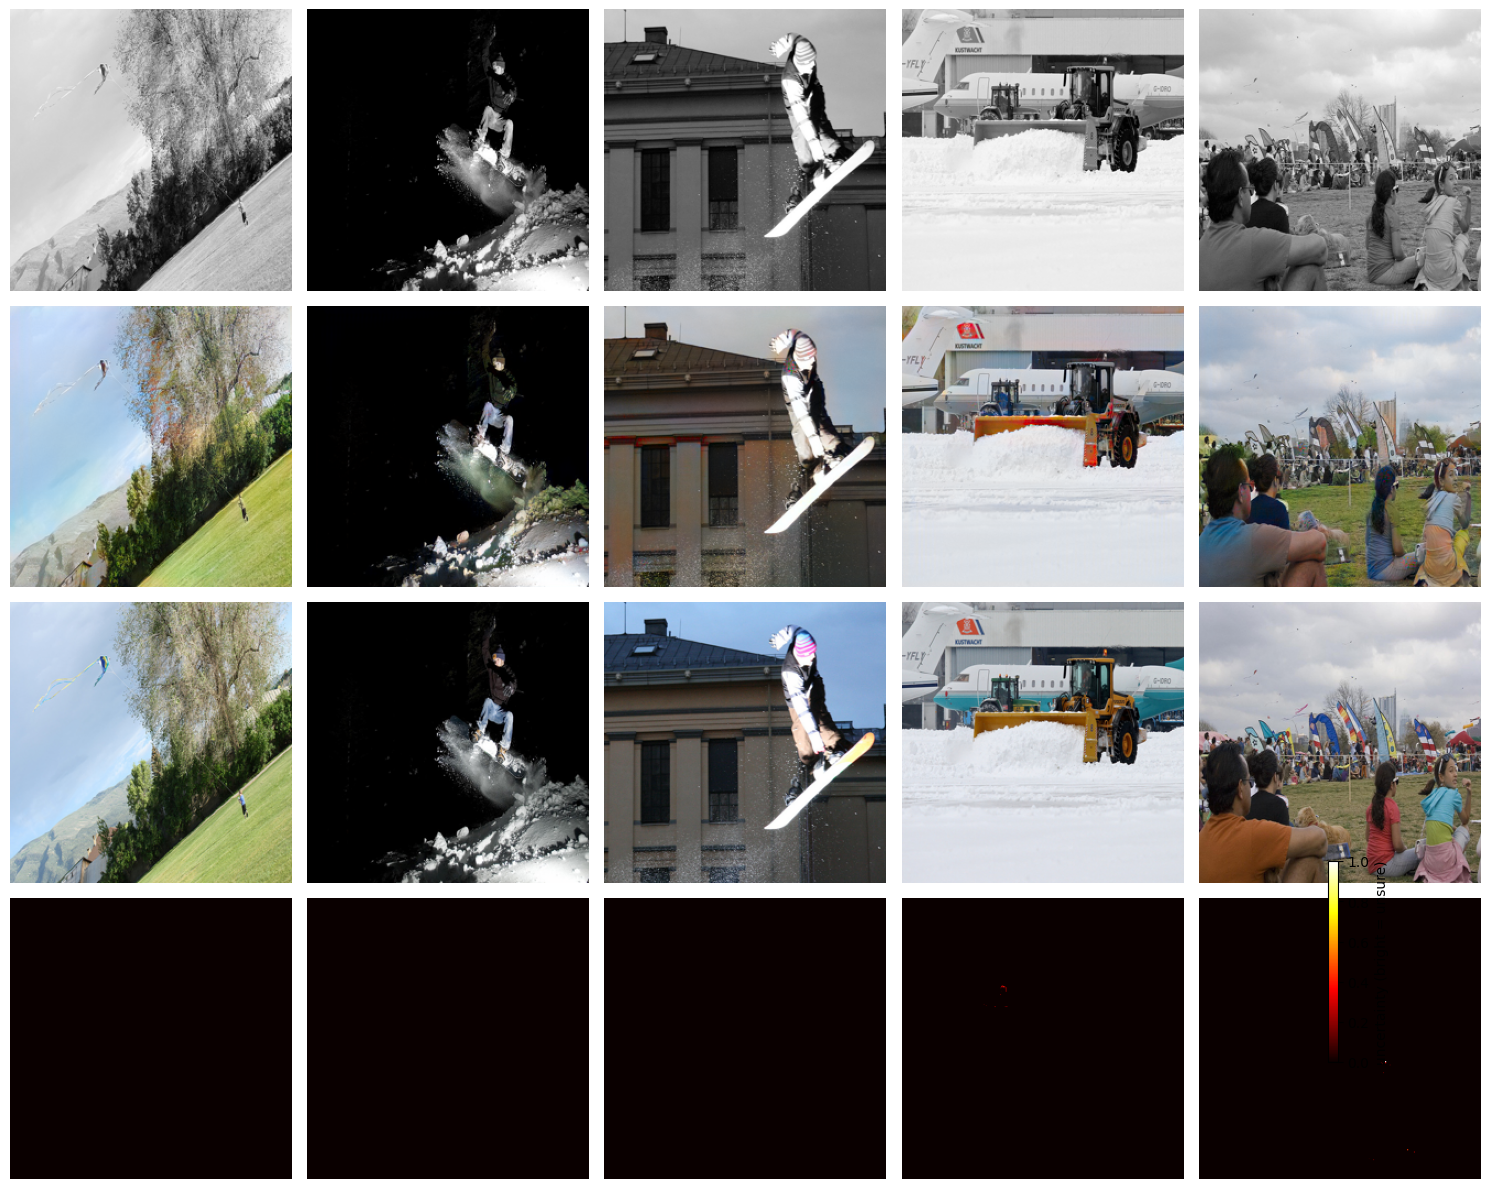

In [ ]:
def lab_to_rgb(L, ab):
    L  = (L + 1.) * 50.
    ab = ab * 110.
    Lab = torch.cat([L, ab], dim=1).permute(0, 2, 3, 1).cpu().numpy()
    return np.stack([lab2rgb(img) for img in Lab], axis=0)


def visualize_uncertainty(model, data, n=5, save=False, path="uncertainty.png"):
    model.net_G.eval()
    with torch.no_grad():
        model.setup_input(data)
        model.forward()
    model.net_G.train()

    n = min(n, len(model.L))
    colorized   = lab_to_rgb(model.L[:n], model.ab_mean[:n].detach())
    ground_truth = lab_to_rgb(model.L[:n], model.ab[:n])
    uncertainty = model.uncertainty[:n, 0].cpu().numpy()

    u_min, u_max = uncertainty.min(), uncertainty.max()
    unc_norm = (uncertainty - u_min) / (u_max - u_min + 1e-8)

    fig, axes = plt.subplots(4, n, figsize=(3 * n, 12))
    for i in range(n):
        axes[0, i].imshow(model.L[i][0].cpu(), cmap='gray');    axes[0, i].axis('off')
        axes[1, i].imshow(colorized[i]);                        axes[1, i].axis('off')
        axes[2, i].imshow(ground_truth[i]);                     axes[2, i].axis('off')
        im = axes[3, i].imshow(unc_norm[i], cmap='hot', vmin=0, vmax=1)
        axes[3, i].axis('off')

    axes[0, 0].set_ylabel("input",        fontsize=11)
    axes[1, 0].set_ylabel("colorized",    fontsize=11)
    axes[2, 0].set_ylabel("ground truth", fontsize=11)
    axes[3, 0].set_ylabel("uncertainty",  fontsize=11)

    fig.colorbar(im, ax=axes[3].tolist(), fraction=0.015, pad=0.01,
                 label="uncertainty (bright = unsure)")

    plt.tight_layout()
    if save:
        plt.savefig(path, bbox_inches='tight', dpi=120)
    plt.show()


visualize_uncertainty(model, next(iter(val_dl)), n=5, save=True,
                      path=os.path.join(UNCERTAINTY_CHECKPOINT_DIR, "uncertainty_final.png"))


## Uncertainty Histogram

Check that the model's uncertainty is not trivially uniform. We expect:
- Low uncertainty for semantically clear regions (sky, grass, skin)
- High uncertainty for ambiguous regions (concrete, metal, shadowed areas)


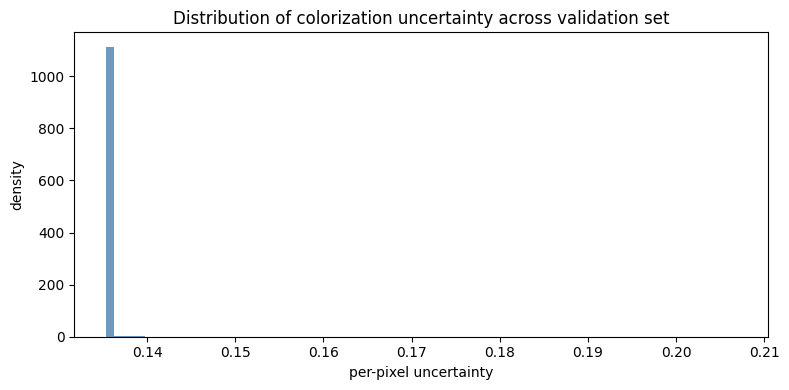

mean uncertainty: 0.1354
std  uncertainty: 0.0004


UncertaintyGenerator(
  (base): DynamicUnet(
    (layers): ModuleList(
      (0): Sequential(
        (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (4): Sequential(
          (0): BasicBlock(
            (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (relu): ReLU(inplace=True)
            (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
          (1): BasicBlock(
            (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), paddin

In [ ]:
model.net_G.eval()
all_unc = []
with torch.no_grad():
    for i, data in enumerate(val_dl):
        if i >= 20:
            break
        model.setup_input(data)
        model.forward()
        all_unc.append(model.uncertainty.cpu().numpy().ravel())

all_unc = np.concatenate(all_unc)

plt.figure(figsize=(8, 4))
plt.hist(all_unc, bins=80, density=True, color='steelblue', alpha=0.8)
plt.xlabel("per-pixel uncertainty")
plt.ylabel("density")
plt.title("Distribution of colorization uncertainty across validation set")
plt.tight_layout()
plt.savefig(os.path.join(UNCERTAINTY_CHECKPOINT_DIR, "uncertainty_histogram.png"),
            bbox_inches='tight', dpi=120)
plt.show()

print(f"mean uncertainty: {all_unc.mean():.4f}")
print(f"std  uncertainty: {all_unc.std():.4f}")
model.net_G.train()
